# Loan Approval Analysis

## Project Overview

This project analyzes loan application data to identify the key factors associated with loan approval decisions.

The analysis focuses on applicant characteristics, financial attributes, CIBIL scores, loan amounts, and approval outcomes to uncover patterns that can support data-driven lending decisions.

## Business Problem

The objective of this analysis is to understand:

- What factors are associated with loan approval?
- How does CIBIL score relate to approval rates?
- Does applicant income influence loan amount?
- Do education and self-employment status significantly affect approval?
- Which applicant segments have higher or lower approval rates?

## Analytical Questions

1. What is the overall loan approval rate?
2. How does approval rate vary across CIBIL risk categories?
3. How does approval rate change across CIBIL score bands?
4. What is the relationship between annual income and loan amount?
5. Does education level affect loan approval?
6. Does self-employment status affect loan approval?

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/loan_approval_dataset.csv")

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 1. Data Understanding

### Dataset Structure

The dataset contains 4,269 loan applications and 13 variables covering applicant demographics, financial information, asset values, CIBIL scores, loan details, and loan approval status.

In [4]:
df.shape


(4269, 13)

In [5]:
df.columns


Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [66]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [67]:
df.duplicated().sum()

np.int64(0)

The dataset contains 4,269 loan applications and 13 original variables. No missing values or duplicate records were identified.

## 2. Data Cleaning

The dataset was checked for missing values, duplicate records, and formatting inconsistencies before performing the analysis.

The following data-quality checks were performed:

- Missing-value check
- Duplicate-record check
- Categorical-value consistency
- Whitespace removal from text columns

In [68]:
df.columns = df.columns.str.strip()

In [69]:
text_columns = df.select_dtypes(include="object").columns
for col in text_columns:
  df[col]=df[col].str.strip()

In [70]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status',
       'Risk_Category', 'CIBIL_Band'],
      dtype='object')

In [71]:
df.select_dtypes(include="object").nunique()

,0
education,2
self_employed,2
loan_status,2
Risk_Category,3


###"Show me only the approved loan applications."

In [23]:
df[
df["loan_status"]=="Approved"
]

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
10,11,4,Graduate,Yes,2900000,11200000,2,547,8100000,4700000,9500000,3100000,Approved
13,14,2,Graduate,Yes,9100000,31500000,14,679,10800000,16600000,20900000,5000000,Approved
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4261,4262,3,Graduate,Yes,3000000,7500000,6,881,1400000,4500000,6100000,2300000,Approved
4263,4264,3,Graduate,No,5000000,12700000,14,865,4700000,8100000,19500000,6300000,Approved
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


## 3. Feature Engineering

### CIBIL Risk Classification

CIBIL scores were categorized into three risk levels:
- Below 650 → High Risk
- 650–749 → Medium Risk
- 750 and above → Low Risk

In [74]:
conditions=[
    df["cibil_score"]>=750,
    (df["cibil_score"]>=650) & (df["cibil_score"]<750),
    df["cibil_score"]<650
]
choices=[
    "Low Risk",
    "Medium Risk",
    "High Risk"
]

df["Risk_Category"] = np.select(conditions, choices,default="No_Risk_Category")

In [75]:
df["Risk_Category"].value_counts()

,count
Risk_Category,
High Risk,2468
Low Risk,1056
Medium Risk,745


#### CIBIL Bands

In [77]:
bins = [299, 399, 499, 599, 649, 699, 749, 799, 899, float("inf")]
df["CIBIL_Band"].value_counts().sort_index()

,count
CIBIL_Band,
300-399,704
400-499,696
500-599,733
600-649,335
650-699,371
700-749,374
750-799,361
800-899,689
900+,6


## 4. Exploratory Data Analysis

### 4.1 Overall Loan Approval Distribution

In [78]:
df["loan_status"].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [79]:
loan_status_counts = df["loan_status"].value_counts()

loan_status_percentage = (
    loan_status_counts / len(df) * 100
).round(2)

loan_status_percentage

,count
loan_status,
Approved,62.22
Rejected,37.78


### 4.2 Loan Amount Analysis

In [80]:
loan_status_summary = df.groupby("loan_status").agg(
    Number_of_Applicants=("loan_id", "count"),
    Total_Loan_Amount=("loan_amount", "sum"),
    Average_Loan_Amount=("loan_amount", "mean")
)

loan_status_summary

,Number_of_Applicants,Total_Loan_Amount,Average_Loan_Amount
loan_status,,,
Approved,2656,40496700000,1.524725e+07
Rejected,1613,24108000000,1.494606e+07


## 5. Risk Analysis

### 5.1 Risk Distribution

In [81]:
df["Risk_Category"].value_counts()

,count
Risk_Category,
High Risk,2468
Low Risk,1056
Medium Risk,745


### 5.2 Risk Summary

In [82]:
risk_summary=df.groupby("Risk_Category").agg(
    Number_of_Applicants=('loan_id','count'),
    Approval_count=('loan_status', lambda x: (x == 'Approved').sum()),
    Average_Loan_Amount=('loan_amount','mean')
)

In [42]:
risk_summary["Approval_Rate"]=(risk_summary["Approval_count"]/risk_summary["Number_of_Applicants"])*100

In [43]:
risk_summary

,Number_of_Applicants,Approval_count,Average_Loan_Amount,Approval_Rate
Risk_Category,,,,
High Risk,2468,866,1.524100e+07,35.089141
Low Risk,1056,1050,1.465587e+07,99.431818
Medium Risk,745,740,1.545409e+07,99.328859


In [44]:
risk_summary["Approval_Rate"].round(2)

,Approval_Rate
Risk_Category,
High Risk,35.09
Low Risk,99.43
Medium Risk,99.33


"Show the risk categories from the highest approval rate to the lowest."


In [45]:
risk_summary.sort_values(by="Approval_Rate",ascending=False)

,Number_of_Applicants,Approval_count,Average_Loan_Amount,Approval_Rate
Risk_Category,,,,
Low Risk,1056,1050,1.465587e+07,99.431818
Medium Risk,745,740,1.545409e+07,99.328859
High Risk,2468,866,1.524100e+07,35.089141


### 5.3 Education Summary

In [83]:
education_summary = df.groupby("education").agg(
    Number_of_Applicants = ('loan_id',"count"),
    Approval_count = ('loan_status', lambda x:(x=="Approved").sum())
)
education_summary["Approval_Rate"] = (
    education_summary["Approval_count"]
    / education_summary["Number_of_Applicants"]
    * 100
)
education_summary["Approval_Rate"] = education_summary["Approval_Rate"].round(2)
education_summary

,Number_of_Applicants,Approval_count,Approval_Rate
education,,,
Graduate,2144,1339,62.45
Not Graduate,2125,1317,61.98


### 5.4 Self-Employment Summary

In [84]:
self_employment_summary = df.groupby("self_employed").agg(
    Number_of_Applicants=("loan_id", "count"),
    Approval_count=("loan_status",  lambda x:(x=="Approved").sum())
)
self_employment_summary["Approval_Rate"] = (
    self_employment_summary["Approval_count"]
    / self_employment_summary["Number_of_Applicants"]
    * 100
)
self_employment_summary["Approval_Rate"] = self_employment_summary["Approval_Rate"].round(2)
self_employment_summary

,Number_of_Applicants,Approval_count,Approval_Rate
self_employed,,,
No,2119,1318,62.20
Yes,2150,1338,62.23


### 5.5 Income vs Loan Amount

In [85]:
df["income_annum"].corr(df["loan_amount"])
df.groupby("loan_status")[["income_annum", "loan_amount"]].corr()

income_annum  loan_amount
loan_status                                        
Approved    income_annum      1.000000     0.932123
            loan_amount       0.932123     1.000000
Rejected    income_annum      1.000000     0.920884
            loan_amount       0.920884     1.000000

## 6. Visualizations

### Applicant Distribution by Risk Category

In [46]:
risk_summary_sorted = risk_summary.sort_values(
    by="Approval_Rate",
    ascending=False
)

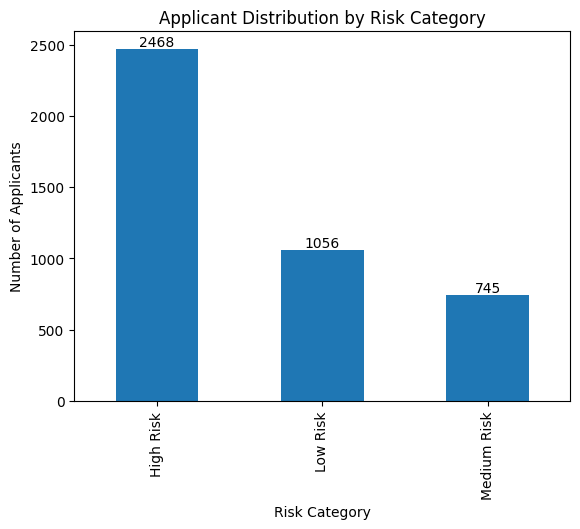

In [48]:
ax=df["Risk_Category"].value_counts().plot(
    kind='bar',
    xlabel="Risk Category",
    ylabel="Number of Applicants",
    title="Applicant Distribution by Risk Category"
)
for containers in ax.containers:
  ax.bar_label(containers)
plt.show()

### Loan Amount by Risk Category

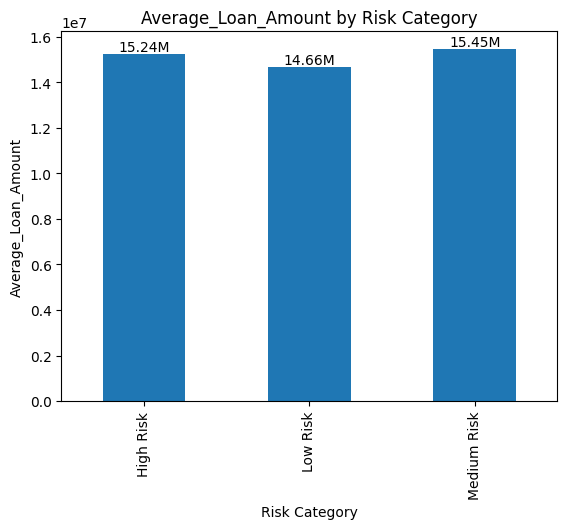

In [49]:
ax=risk_summary["Average_Loan_Amount"].plot(
    kind='bar',
    xlabel='Risk Category',
    ylabel='Average_Loan_Amount',
    title= "Average_Loan_Amount by Risk Category"
)

labels = [
    f"{amount / 1_000_000:.2f}M"
    for amount in risk_summary["Average_Loan_Amount"]
]

ax.bar_label(ax.containers[0], labels=labels)

plt.show()


### Loan Approval Distribution

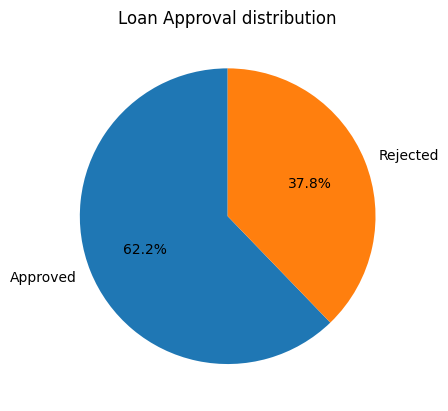

In [50]:
loan_status_counts = df["loan_status"].value_counts()

loan_status_counts.plot(
    kind='pie',
    autopct="%1.1f%%",
    startangle=90,
    title="Loan Approval distribution"
)
plt.ylabel("")
plt.show()

### Loan Approval Rate by CIBIL Risk Category

In [89]:
min_cibil = df["cibil_score"].min()
max_cibil = df["cibil_score"].max()
bins = [min_cibil - 1, 649, 749, max_cibil]
labels = ["High Risk", "Medium Risk", "Low Risk"]

df["CIBIL_Band"] = pd.cut(
    df["cibil_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)




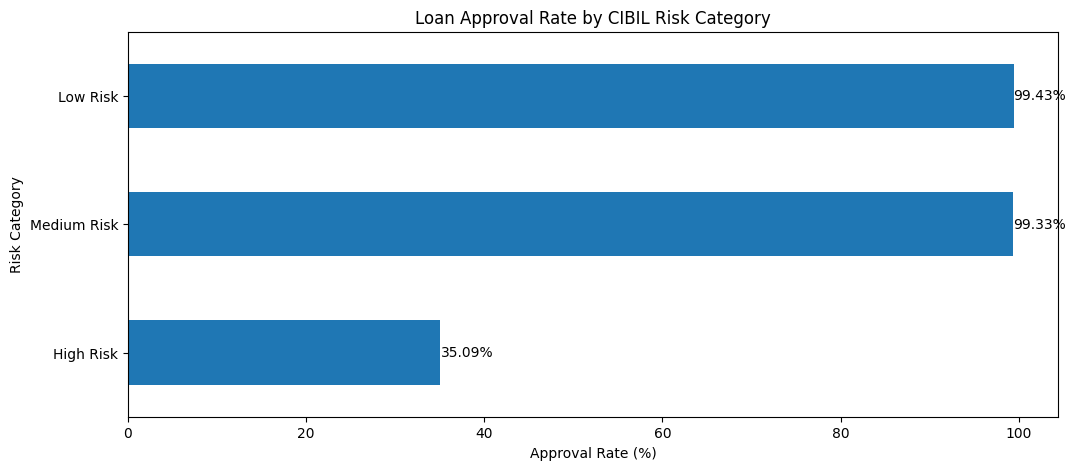

In [88]:
risk_summary["Approval_Rate"] = (
    risk_summary["Approval_count"]
    / risk_summary["Number_of_Applicants"]
    * 100
)

risk_summary_sorted = risk_summary.sort_values(
    by="Approval_Rate",
    ascending=True
)

ax = risk_summary_sorted["Approval_Rate"].plot(
    kind="barh",
    xlabel="Approval Rate (%)",
    ylabel="Risk Category",
    title="Loan Approval Rate by CIBIL Risk Category",
    figsize=(12, 5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%"
    )

plt.show()

### Loan Approval Rate by Self-Employment

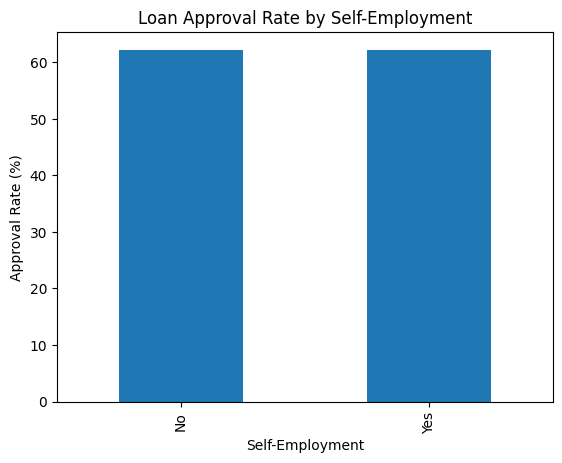

In [94]:
ax = self_employment_summary["Approval_Rate"].plot(
    kind="bar",
    xlabel="Self-Employment",
    ylabel="Approval Rate (%)",
    title="Loan Approval Rate by Self-Employment"
)

### Annual Income vs Loan Amount

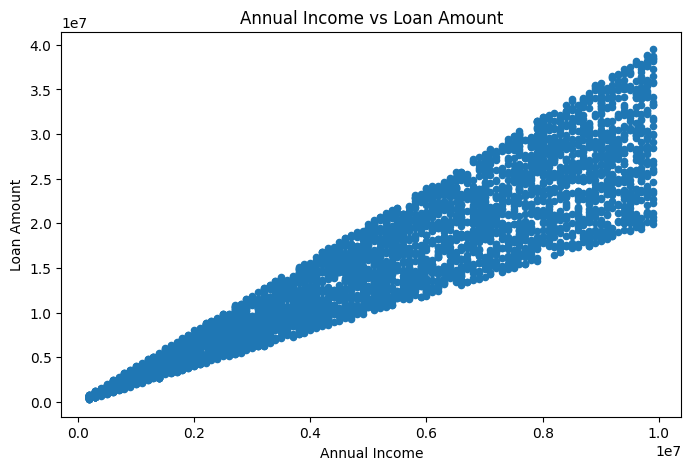

In [59]:
ax = df.plot(
    kind="scatter",
    x="income_annum",
    y="loan_amount",
    figsize=(8, 5),
    title="Annual Income vs Loan Amount"
)

ax.set_xlabel("Annual Income")
ax.set_ylabel("Loan Amount")

plt.show()

### Annual Income vs Loan Amount by Loan Status

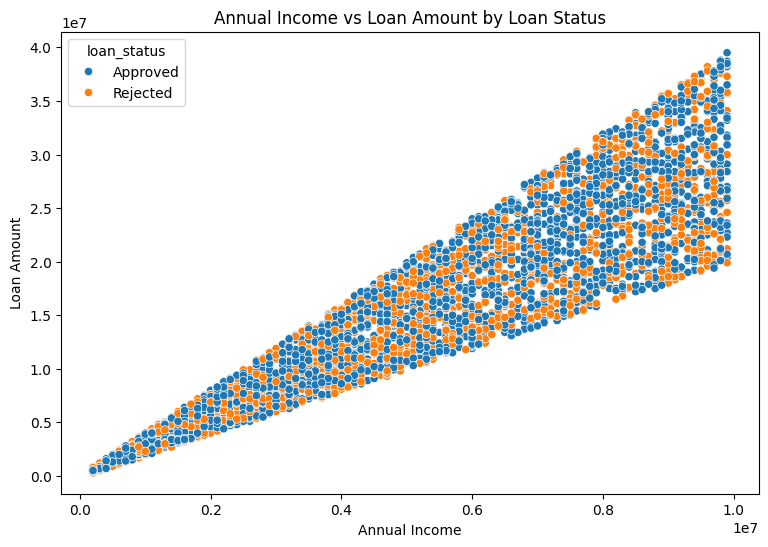

In [61]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="income_annum",
    y="loan_amount",
    hue="loan_status"
)

plt.title("Annual Income vs Loan Amount by Loan Status")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")

plt.show()

In [92]:
bins = [299, 399, 499, 599, 649, 699, 749, 799, 899, float("inf")]
labels = [
    "300-399",
    "400-499",
    "500-599",
    "600-649",
    "650-699",
    "700-749",
    "750-799",
    "800-899",
    "900+"
]

df["CIBIL_Band"] = pd.cut(
    df["cibil_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [64]:
cibil_summary = df.groupby("CIBIL_Band", observed=True).agg(
    Number_of_Applicants=("loan_id", "count"),
    Approval_count=("loan_status", lambda x: (x == "Approved").sum())
)
cibil_summary["Approval_Rate"] = (
    cibil_summary["Approval_count"]
    / cibil_summary["Number_of_Applicants"]
    * 100
)
cibil_summary["Approval_Rate"] = cibil_summary["Approval_Rate"].round(2)
cibil_summary

,Number_of_Applicants,Approval_count,Approval_Rate
CIBIL_Band,,,
300-399,704,72,10.23
400-499,696,76,10.92
500-599,733,383,52.25
600-649,335,335,100.00
650-699,371,367,98.92
700-749,374,373,99.73
750-799,361,358,99.17
800-899,689,686,99.56
900+,6,6,100.00


### Loan Approval Rate Across CIBIL Score Bands

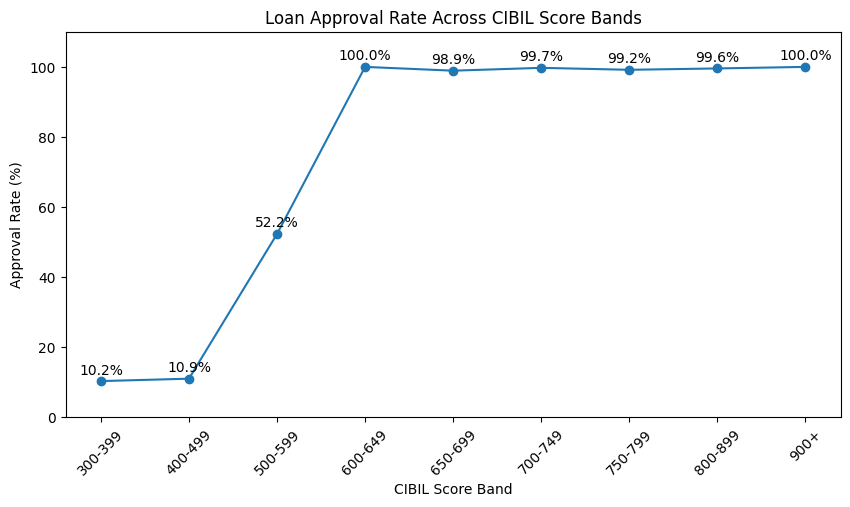

In [65]:
ax = cibil_summary["Approval_Rate"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    xlabel="CIBIL Score Band",
    ylabel="Approval Rate (%)",
    title="Loan Approval Rate Across CIBIL Score Bands"
)

for x, y in enumerate(cibil_summary["Approval_Rate"]):
    ax.text(x, y + 2, f"{y:.1f}%", ha="center")

plt.ylim(0, 110)
plt.xticks(rotation=45)
plt.show()

## 7. Key Findings

### 1. CIBIL score is strongly associated with loan approval
Approval rates are approximately 10–11% for applicants with CIBIL scores below 500, increase to 52.25% for scores between 500–599, and exceed 98% for scores of 600 and above.

### 2. High-risk applicants have substantially lower approval rates
High-risk applicants have an approval rate of 35.09%, compared with 99.43% for low-risk applicants and 99.33% for medium-risk applicants.

### 3. Annual income has a strong positive relationship with loan amount
Annual income and loan amount have a correlation of approximately 0.93, indicating that applicants with higher annual income generally request larger loans.

### 4. Education has minimal impact on approval rate
Graduate applicants have an approval rate of 62.45%, compared with 61.98% for non-graduates.

### 5. Self-employment has minimal impact on approval rate
The approval rates for self-employed and non-self-employed applicants are almost identical at 62.23% and 62.20%, respectively.

### 6. Overall loan approval rate
Out of 4,269 applications, approximately 62.2% were approved and 37.8% were rejected.

## 8. Business Recommendations

1. Use CIBIL score as an important component of loan risk assessment, given its strong association with approval outcomes.

2. Apply additional scrutiny to applicants with lower CIBIL scores, particularly those below 500.

3. Consider annual income and requested loan amount together when evaluating the applicant's borrowing requirements and affordability.

4. Avoid using education or self-employment status as standalone approval criteria, as their observed approval rates are very similar in this dataset.

5. Use a combination of applicant credit profile, income, requested loan amount, and other relevant financial attributes rather than relying on a single variable for lending decisions.

## 9. Conclusion

This analysis examined 4,269 loan applications to identify factors associated with loan approval outcomes.

The analysis indicates that CIBIL score is the strongest differentiating factor in the dataset. Applicants with lower CIBIL scores have substantially lower approval rates, while approval rates are consistently high among applicants with CIBIL scores of 600 and above.

Annual income also shows a strong positive relationship with loan amount, suggesting that higher-income applicants generally request larger loans. In contrast, education and self-employment status show very little difference in approval rates.

Overall, the analysis demonstrates how exploratory data analysis can be used to identify applicant risk patterns, understand lending behavior, and support data-driven decision-making.